# Бэк тест торговой стратегии с управлением рисками

Стратегия основана на пересечении скользящих средних (SMA 5 и SMA 25)

- Начальный депозит: $100,000
- Риск на сделку: 1% от депозита
- R:R = 3 (тейк-профит в 3 раза больше стоп-лосса)
- Комиссия: 0.1% за сделку
- Проскальзывание: 0.05%

In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

In [2]:
# 1. СКАЧИВАЕМ ДАННЫЕ
# Скачиваем историю цены Биткоина за 5 лет
print("Скачиваем данные...")
data = yf.download("BTC-USD", start="2019-01-01", end="2024-01-01")

Скачиваем данные...


/tmp/ipykernel_5733/1014554412.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("BTC-USD", start="2019-01-01", end="2024-01-01")


[*********************100%***********************]  1 of 1 completed


In [3]:
# 2. СОЗДАЕМ ИНДИКАТОРЫ
# Быстрая скользящая средняя (за 10 дней)
data['SMA_10'] = data['Close'].rolling(window=10).mean()
# Медленная скользящая средняя (за 50 дней)
data['SMA_100'] = data['Close'].rolling(window=100).mean()

In [4]:
# 3. ГЕНЕРИРУЕМ СИГНАЛЫ
# Создаем колонку 'Signal', по умолчанию 0 (ничего не делаем)
data['Signal'] = 0

# Если Быстрая > Медленной -> Ставим 1 (Покупать)
data.loc[data['SMA_10'] > data['SMA_100'], 'Signal'] = 1

In [5]:
# 4. БЭКТЕСТ С УПРАВЛЕНИЕМ РИСКАМИ

# Параметры
INITIAL_CAPITAL = 100000  # Начальный депозит
RISK_PER_TRADE = 0.01     # 1% риска от депозита
RR_RATIO = 3              # R:R = 3
COMMISSION = 0.001        # 0.1% комиссия
SLIPPAGE = 0.0005         # 0.05% проскальзывание

# Инициализация переменных
capital = INITIAL_CAPITAL
position = None  # {'entry_price': x, 'entry_idx': i, 'size': n, 'sl': y, 'tp': z}
trades = []
equity_curve = [INITIAL_CAPITAL]
sl_levels = [np.nan] * len(data)
tp_levels = [np.nan] * len(data)
entry_markers = []
exit_markers = []

# Находим точки входа по пересечению SMA
signal_change = data['Signal'].diff()

for idx in range(1, len(data)):
    row = data.iloc[idx]
    current_price = float(row['Close'])

    # Если нет позиции, проверяем вход
    if position is None:
        if signal_change.iloc[idx] == 1:  # Вход в позицию
            entry_price = current_price * (1 + SLIPPAGE)

            # Рассчитываем размер позиции исходя из 1% риска
            # Используем ATR для стоп-лосса (2 * ATR)
            atr = float(data['High'].iloc[max(0, idx-14):idx+1].max() -
                       data['Low'].iloc[max(0, idx-14):idx+1].min()) / 2
            stop_loss = entry_price - (2 * atr) if atr > 0 else entry_price * 0.95
            take_profit = entry_price + (RR_RATIO * (entry_price - stop_loss))

            # Риск на сделку в долларах
            risk_amount = capital * RISK_PER_TRADE

            # Размер позиции (количество монет)
            risk_per_coin = entry_price - stop_loss
            if risk_per_coin > 0:
                position_size = risk_amount / risk_per_coin
            else:
                position_size = (capital * 0.95) / entry_price  # На 95% депозита

            # Комиссия при входе
            commission = position_size * entry_price * COMMISSION
            capital -= commission

            position = {
                'entry_price': entry_price,
                'entry_idx': idx,
                'size': position_size,
                'sl': stop_loss,
                'tp': take_profit
            }

            sl_levels[idx] = stop_loss
            tp_levels[idx] = take_profit
            entry_markers.append((idx, entry_price, 'entry'))

    # Если есть позиция, проверяем выход
    else:
        high_price = float(row['High'])
        low_price = float(row['Low'])

        exit_price = None
        exit_type = None

        # Проверка стоп-лосса
        if low_price <= position['sl']:
            exit_price = position['sl'] * (1 - SLIPPAGE)
            exit_type = 'SL'
        # Проверка тейк-профита
        elif high_price >= position['tp']:
            exit_price = position['tp'] * (1 + SLIPPAGE)
            exit_type = 'TP'
        # Выход по сигналу (SMA пересеклась вниз)
        elif signal_change.iloc[idx] == -1:
            exit_price = current_price * (1 - SLIPPAGE)
            exit_type = 'SIGNAL'

        if exit_price:
            # Комиссия при выходе
            commission = position['size'] * exit_price * COMMISSION

            # P&L
            pnl = position['size'] * (exit_price - position['entry_price']) - commission
            capital += pnl

            trades.append({
                'entry_idx': position['entry_idx'],
                'exit_idx': idx,
                'entry_price': position['entry_price'],
                'exit_price': exit_price,
                'sl': position['sl'],
                'tp': position['tp'],
                'pnl': pnl,
                'exit_type': exit_type,
                'size': position['size']
            })

            exit_markers.append((idx, exit_price, exit_type))
            position = None

    # Записываем текущее значение капитала
    if position:
        unrealized_pnl = position['size'] * (current_price - position['entry_price'])
        equity_curve.append(INITIAL_CAPITAL + sum(t['pnl'] for t in trades) + unrealized_pnl)
    else:
        equity_curve.append(INITIAL_CAPITAL + sum(t['pnl'] for t in trades))

# Если позиция осталась открытой
if position:
    exit_price = float(data['Close'].iloc[-1]) * (1 - SLIPPAGE)
    commission = position['size'] * exit_price * COMMISSION
    pnl = position['size'] * (exit_price - position['entry_price']) - commission
    capital += pnl
    trades.append({
        'entry_idx': position['entry_idx'],
        'exit_idx': len(data) - 1,
        'entry_price': position['entry_price'],
        'exit_price': exit_price,
        'sl': position['sl'],
        'tp': position['tp'],
        'pnl': pnl,
        'exit_type': 'CLOSE',
        'size': position['size']
    })
    equity_curve[-1] = capital

trades_df = pd.DataFrame(trades)

/tmp/ipykernel_5733/376013843.py:25: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(row['Close'])
/tmp/ipykernel_5733/376013843.py:34: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  atr = float(data['High'].iloc[max(0, idx-14):idx+1].max() -
/tmp/ipykernel_5733/376013843.py:67: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  high_price = float(row['High'])
/tmp/ipykernel_5733/376013843.py:68: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  low_price = float(row['Low'])


In [6]:
# 5. РЕЗУЛЬТАТЫ
print(f"Начальный депозит: ${INITIAL_CAPITAL:,.2f}")
print(f"Конечный капитал: ${capital:,.2f}")
print(f"Общая доходность: {((capital / INITIAL_CAPITAL) - 1) * 100:.2f}%")
print(f"\nВсего сделок: {len(trades)}")

if len(trades) > 0:
    winning = [t for t in trades if t['pnl'] > 0]
    losing = [t for t in trades if t['pnl'] < 0]

    print(f"Прибыльных: {len(winning)} ({len(winning)/len(trades)*100:.1f}%)")
    print(f"Убыточных: {len(losing)} ({len(losing)/len(trades)*100:.1f}%)")

    sl_hits = len([t for t in trades if t['exit_type'] == 'SL'])
    tp_hits = len([t for t in trades if t['exit_type'] == 'TP'])
    signal_exits = len([t for t in trades if t['exit_type'] == 'SIGNAL'])

    print(f"\nВыходов по стоп-лоссу: {sl_hits}")
    print(f"Выходов по тейк-профиту: {tp_hits}")
    print(f"Выходов по сигналу: {signal_exits}")

Начальный депозит: $100,000.00
Конечный капитал: $107,812.66
Общая доходность: 7.81%

Всего сделок: 10
Прибыльных: 6 (60.0%)
Убыточных: 4 (40.0%)

Выходов по стоп-лоссу: 2
Выходов по тейк-профиту: 3
Выходов по сигналу: 5


In [7]:
# 5.1 ПОДРОБНАЯ СТАТИСТИКА
from IPython.display import display, Markdown

if len(trades) > 0:
    trades_series = pd.Series([t['pnl'] for t in trades])
    winning_trades = trades_series[trades_series > 0]
    losing_trades = trades_series[trades_series < 0]

    total_trades = len(trades)
    win_rate = len(winning_trades) / total_trades * 100
    avg_win = float(winning_trades.mean()) if len(winning_trades) > 0 else 0
    avg_loss = abs(float(losing_trades.mean())) if len(losing_trades) > 0 else 0
    avg_rr = avg_win / avg_loss if avg_loss > 0 else 0

    gross_profit = float(winning_trades.sum()) if len(winning_trades) > 0 else 0
    gross_loss = abs(float(losing_trades.sum())) if len(losing_trades) > 0 else 0
    profit_factor = gross_profit / gross_loss if gross_loss > 0 else float('inf')

    total_return = float(trades_series.sum())

    # Коэффициент Шарпа (на основе ежедневной доходности)
    equity_series = pd.Series(equity_curve)
    daily_returns = equity_series.pct_change().dropna()
    sharpe_ratio = float((daily_returns.mean() / daily_returns.std()) * np.sqrt(252)) if daily_returns.std() > 0 else 0

    # Максимальная просадка
    equity_max = equity_series.cummax()
    drawdown = (equity_series - equity_max) / equity_max
    max_drawdown = float(drawdown.min())

    # Формируем таблицу
    stats_df = pd.DataFrame({
        'Метрика': [
            'Всего сделок',
            'Win Rate (%)',
            'Средний R:R',
            'Profit Factor',
            'Коэф. Шарпа',
            'Макс. просадка (%)',
            'Общая доходность ($)',
            'Общая доходность (%)',
            'Средний выигрыш ($)',
            'Средний проигрыш ($)'
        ],
        'Значение': [
            f'{total_trades}',
            f'{win_rate:.2f}',
            f'{avg_rr:.2f}',
            f'{profit_factor:.2f}',
            f'{sharpe_ratio:.2f}',
            f'{max_drawdown * 100:.2f}',
            f'${total_return:,.2f}',
            f'{(total_return / INITIAL_CAPITAL) * 100:.2f}%',
            f'${avg_win:,.2f}',
            f'${avg_loss:,.2f}'
        ]
    })

    display(Markdown("### 📊 Статистика стратегии"))
    display(stats_df.style.hide(axis="index"))

### 📊 Статистика стратегии

Метрика,Значение
Всего сделок,10
Win Rate (%),60.00
Средний R:R,2.21
Profit Factor,3.31
Коэф. Шарпа,0.72
Макс. просадка (%),-2.99
Общая доходность ($),"$7,869.47"
Общая доходность (%),7.87%
Средний выигрыш ($),"$1,878.45"
Средний проигрыш ($),$850.31


KeyError: 'SMA_50'

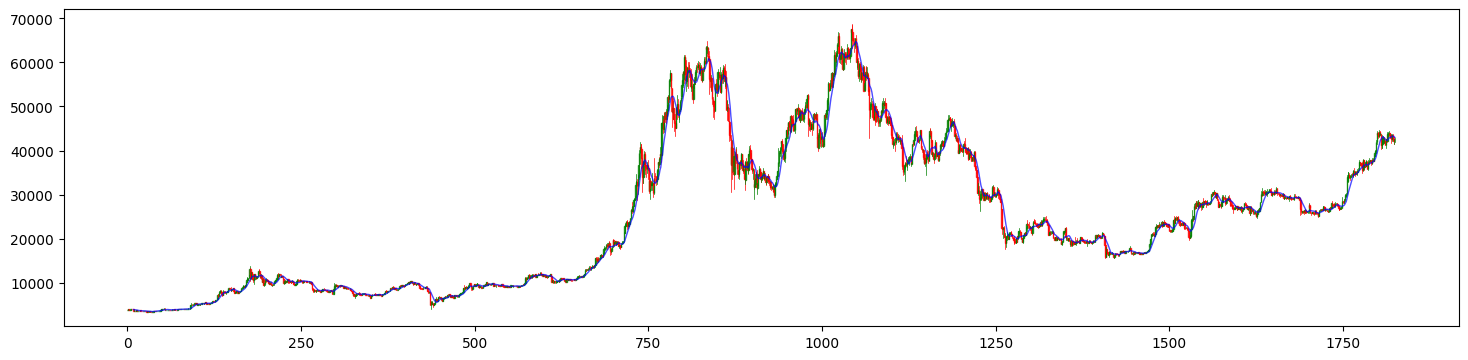

In [8]:
# 6. ВИЗУАЛИЗАЦИЯ ВСЕЙ ИСТОРИИ
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle

# Перезагружаем данные, если они отсутствуют в памяти
try:
    data.head()
except NameError:
    print("Данные не найдены, загружаем заново...")
    data = yf.download("BTC-USD", start="2019-01-01", end="2024-01-01", auto_adjust=True)
    data['SMA_10'] = data['Close'].rolling(window=10).mean()
    data['SMA_100'] = data['Close'].rolling(window=100).mean()
    data['Signal'] = 0
    data.loc[data['SMA_10'] > data['SMA_100'], 'Signal'] = 1

# Берем ВСЕ данные для отображения
df_plot = data.copy()
if isinstance(df_plot.columns, pd.MultiIndex):
    df_plot.columns = df_plot.columns.get_level_values(0)

df_plot = df_plot.reset_index(drop=False)

# Создаем фигуру
fig = plt.figure(figsize=(18, 14))

# График 1: Японские свечи
ax1 = fig.add_subplot(311)
for idx in range(len(df_plot)):
    row = df_plot.iloc[idx]
    open_p, close_p = float(row['Open']), float(row['Close'])
    high_p, low_p = float(row['High']), float(row['Low'])

    color = 'green' if close_p >= open_p else 'red'
    ax1.plot([idx, idx], [low_p, high_p], color=color, linewidth=0.5)
    ax1.add_patch(Rectangle((idx - 0.4, min(open_p, close_p)), 0.8, abs(close_p - open_p),
                            facecolor=color, edgecolor=color, alpha=0.8))

ax1.plot(df_plot.index, df_plot['SMA_10'], label='SMA 10', color='blue', linewidth=1, alpha=0.7)
ax1.plot(df_plot.index, df_plot['SMA_50'], label='SMA 50', color='orange', linewidth=1, alpha=0.7)

# Отображение сделок прямоугольниками с SL и TP
try:
    for trade in trades:
        e_idx = trade.get('entry_idx')
        ex_idx = trade.get('exit_idx')
        e_pr = trade.get('entry_price')
        sl = trade.get('sl')
        tp = trade.get('tp')
        pnl = trade.get('pnl', 0)

        if all(v is not None for v in [e_idx, ex_idx, e_pr, sl, tp]):
            rect_color = 'green' if pnl > 0 else 'red'
            # Прямоугольник от SL до TP
            ax1.add_patch(Rectangle((e_idx, sl), ex_idx - e_idx, tp - sl,
                                    fill=False, edgecolor=rect_color, linewidth=2, linestyle="--"))
            # Линия входа
            ax1.plot([e_idx, ex_idx], [e_pr, e_pr], color="blue", linewidth=1.5)
            # Линия стоп-лосса
            ax1.plot([e_idx, ex_idx], [sl, sl], color="red", linewidth=1, linestyle=":")
            # Линия тейк-профита
            ax1.plot([e_idx, ex_idx], [tp, tp], color="green", linewidth=1, linestyle=":")
except NameError:
    pass

ax1.legend(loc='upper left')
ax1.set_title('BTC-USD: Вся история и зоны сделок (SL/TP)', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# График 2: Капитал
try:
    ax2 = fig.add_subplot(312)
    ax2.plot(range(len(equity_curve)), equity_curve, color='green', linewidth=2)
    ax2.set_title('Кривая капитала', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
except NameError:
    pass

# Настройка дат
tick_indices = np.linspace(0, len(df_plot) - 1, 15, dtype=int)
for ax in fig.axes:
    ax.set_xticks(tick_indices)
    ax.set_xticklabels([df_plot['Date'].iloc[i].strftime('%Y-%m') for i in tick_indices], rotation=45)

plt.tight_layout()
plt.show()

print('hello')